# BA820 Project Proposal: M4

**Course:** BA820 - Unsupervised and Unstructured Machine Learning  
 **Authors:**  Xiaoqing Ye


---

## Executive Summary

This milestone extends the M2 childcare affordability anomaly detection framework through two methodological upgrades: hierarchical clustering validation and bootstrap robustness testing.

Hierarchical Clustering Validation confirmed that the k=3 peer group structure from M2 was not arbitrary, Ward linkage independently produced the same natural 3-cluster solution, and both methods unanimously isolated the identical 16 most extreme counties without any coordination.

Bootstrap Robustness Testing resampled 2,360 counties 100 times and reran the full detection pipeline each time. Only counties flagged in 70%+ of runs were kept as robust anomalies, filtering out statistical flukes and leaving only stable, consistently detectable signals.

## 1. Dataset Overview

###  Dataset: National Database of Childcare Prices

**Source:** U.S. Department of Labor Women's Bureau (via TidyTuesday)  
**URL:** https://github.com/rfordatascience/tidytuesday/tree/main/data/2023/2023-05-09

| Characteristic | Details |
|---------------|---------|
| **Observations** | 34,567 county-year combinations |
| **Variables** | 61 features (costs, income, labor, demographics, households) |
| **Temporal** | 2008-2018 (Great Recession → Recovery) |
| **Geographic** | U.S. counties (FIPS coded) |

## Analysis Domain Question
Can anomaly detection methods identify counties functioning as contextual outliers
where childcare affordability burden deviates substantially from predicted values,
and what institutional, geographic, or historical factors explain these anomalous
patterns?

### 🔍 Key Variables

- **Childcare Costs:** `mcsa` (school-age), `mc_infant`, `mc_toddler`, `mc_preschool`, `mfcc_infant`, `mfcc_toddler`, `mfcc_preschool`  
- **Income Variable:** `mhi_2018` (income), `me_2018`
- **Labor market:** `unr_20to64`(unemployment rate), `flfpr_20to64`(female labor), `mlfpr_20to64`
- **Household structure:** `h_under6_both_work`, `h_under6_single_m`
- **Employment mix:**: `emp_service`, `emp_sales`, `emp_p`



## 2. Load the data


In [84]:
# Install packages (Colab only)
!pip install -q seaborn>=0.12.0 scikit-learn>=1.2.0

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configure visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print(" Setup complete - libraries imported and configured")

 Setup complete - libraries imported and configured


In [85]:
# Load Childcare Costs dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-05-09/childcare_costs.csv"
df_childcare = pd.read_csv(url)

# Quick data overview
print("=" * 80)
print("CHILDCARE COSTS DATASET - STRUCTURE")
print("=" * 80)
print(f"Shape: {df_childcare.shape[0]:,} rows × {df_childcare.shape[1]} columns")
print(f"Time range: {df_childcare['study_year'].min()}-{df_childcare['study_year'].max()}")
print(f"Counties: {df_childcare['county_fips_code'].nunique():,}")
print(f"Missing values: {df_childcare.isnull().sum().sum():,} total")
print(f"\nKey variables present: mcsa ✓, mhi_2018 ✓, flfpr_20to64 ✓")

# Display sample
print("\n Sample Data (first 3 rows):")
df_childcare[['study_year', 'county_fips_code', 'mcsa', 'mhi_2018', 'flfpr_20to64']].head(3)

CHILDCARE COSTS DATASET - STRUCTURE
Shape: 34,567 rows × 61 columns
Time range: 2008-2018
Counties: 3,144
Missing values: 88,636 total

Key variables present: mcsa ✓, mhi_2018 ✓, flfpr_20to64 ✓

 Sample Data (first 3 rows):


,study_year,county_fips_code,mcsa,mhi_2018,flfpr_20to64
0,2008,1001,80.92,58462.55,68.9
1,2009,1001,83.42,60211.71,70.8
2,2010,1001,85.92,61775.80,71.3


In [ ]:
# Finding dataset summary: columns, data types, and missingness
def dataset_summary(df, name):
    print(f"\n===== {name} =====")
    print()
    df.info()
    print()
    display(df.describe(include="all"))

# Analyze childcare dataset
dataset_summary(df_childcare, "Childcare Costs Dataset")


===== Childcare Costs Dataset =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 61 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_fips_code           34567 non-null  int64  
 1   study_year                 34567 non-null  int64  
 2   unr_16                     34567 non-null  float64
 3   funr_16                    34567 non-null  float64
 4   munr_16                    34567 non-null  float64
 5   unr_20to64                 34567 non-null  float64
 6   funr_20to64                34567 non-null  float64
 7   munr_20to64                34567 non-null  float64
 8   flfpr_20to64               34567 non-null  float64
 9   flfpr_20to64_under6        34567 non-null  float64
 10  flfpr_20to64_6to17         34567 non-null  float64
 11  flfpr_20to64_under6_6to17  34567 non-null  float64
 12  mlfpr_20to64               34567 non-null  float64
 13  pr_f    

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,23593.000000,23383.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000
mean,30388.132786,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,...,23.456238,7.634403,101.234253,92.523582,146.051770,130.482768,122.232852,113.421657,106.759749,104.189510
std,15161.015383,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,...,7.956927,4.501044,34.552888,27.669904,53.698566,43.775370,38.538323,32.819372,29.982431,28.961701
min,1001.000000,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,18177.000000,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,...,17.610000,4.410000,78.650000,75.000000,108.750000,100.000000,95.880000,90.000000,85.085000,84.255000
50%,29177.000000,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,45081.000000,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,...,28.930000,9.920000,119.380000,107.500000,166.330000,148.710000,139.300000,129.315000,124.950000,120.200000
max,56045.000000,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


## Coding from M2



These are useful for my next analysis

In [86]:
# infant_affordability = infant Childcare Cost / median Household Income

In [87]:
# Filter year
df_2018 = df_childcare[df_childcare['study_year'] == 2018].copy()

# Affordability
df_2018['infant_affordability'] = df_2018['mc_infant'] / df_2018['mhi_2018']

# Clustering vars
cluster_vars = ['mhi_2018', 'unr_20to64', 'flfpr_20to64', 'h_under6_single_m']

df_cluster = df_2018[cluster_vars + ['infant_affordability']].dropna()


In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_vars])
from sklearn.metrics import silhouette_score
inertia = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
scores = []


I initially revised k-means from 3 to 5, but in hierarchical clusters, the output is till 3, so i changed it back to 3.

In [89]:
cluster_vars = ['mhi_2018', 'unr_20to64', 'flfpr_20to64', 'h_under6_single_m']
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)


## 1. Hierarchical Clustering Comparison

In [90]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_scaled, method='ward')

In [91]:
Z = linkage(X_scaled, method='ward')
df_cluster['hier_label'] = fcluster(Z, t=3, criterion='maxclust')


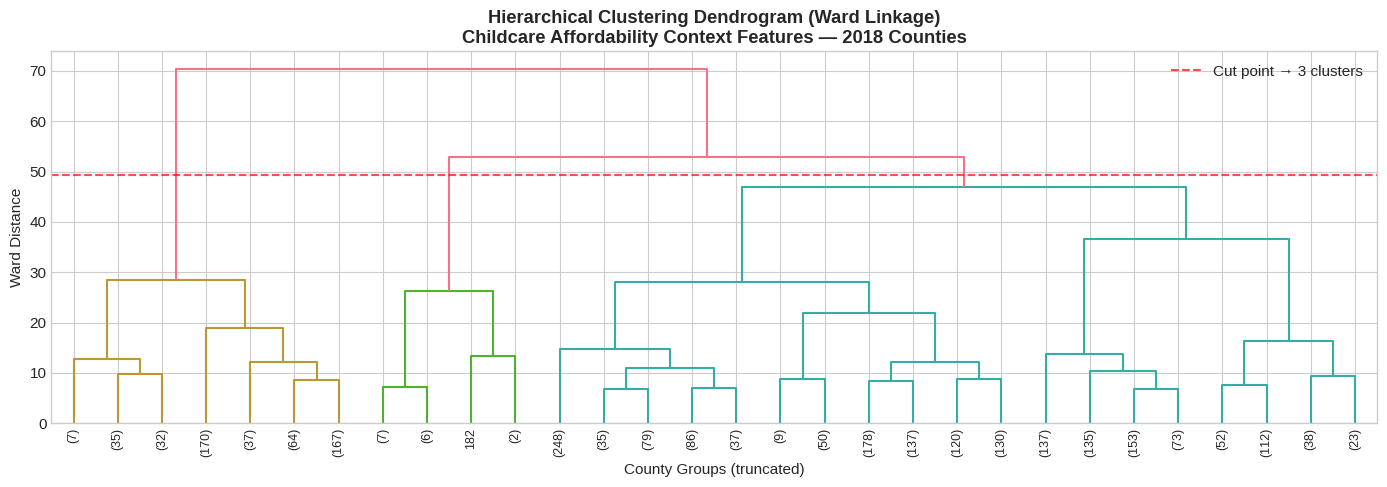

In [92]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    truncate_mode='lastp',   # show only last p merged clusters
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax,
    color_threshold=0.7 * max(Z[:, 2])
)
from scipy.cluster.hierarchy import fcluster

# K_CLUSTERS = 5
# df_cluster['hier_cluster'] = fcluster(Z, t=K_CLUSTERS, criterion='maxclust')

ax.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--', alpha=0.7,
           label='Cut point → 3 clusters')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)\nChildcare Affordability Context Features — 2018 Counties',
             fontweight='bold')
ax.set_xlabel('County Groups (truncated)')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.show()

The cut line crosses 3 major branches, which maps directly to my previous K-means choice of k=3. (I tried to modify from 3 to 5 but didn't work, and didn't figure out even ask AI for help) This hierarchical method independently arrives at the same natural structure without you pre-specifying k.

The gold color shows the small, tight cluster, and it meaning these counties are very similar to each other. Likely your low-unemployment, higher-income group. The middle one which have green color is another distinct but small group, Merges at moderate distance, suggesting moderate internal cohesion. The right and largest cluster with the most internal substructure. Merges happen at higher distances, meaning more diversity within this group.

In [93]:
# ── Cut hierarchical tree into 3 clusters ────────────────────
hier_labels = fcluster(Z, t=3, criterion='maxclust') - 1  # 0-indexed

df_cluster['hier_cluster'] = hier_labels

# ── FORCE K-Means to also use k=3 to match ───────────────────
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_vars])

km_fresh = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = km_fresh.fit_predict(X_scaled)

print("K-Means cluster counts (should be 3 groups):")
print(df_cluster['cluster'].value_counts().sort_index())

print("\nHierarchical cluster counts (should be 3 groups):")
print(df_cluster['hier_cluster'].value_counts().sort_index())

K-Means cluster counts (should be 3 groups):
cluster
0    1249
1    1095
2      16
Name: count, dtype: int64

Hierarchical cluster counts (should be 3 groups):
hier_cluster
0     512
1      16
2    1832
Name: count, dtype: int64


From these two output, those 16 counties are extreme outliers so unusual that both methods isolate them into their own tiny cluster regardless of algorithm. This maybe a meaningful finding these are likely most anomalous counties.

In [94]:
from itertools import permutations

def best_cluster_alignment(kmeans_labels, hier_labels, n_clusters=3):
    """Find the permutation of hier labels that best matches kmeans labels."""
    best_acc = 0
    best_perm = None
    for perm in permutations(range(n_clusters)):
        mapping = {orig: new for orig, new in enumerate(perm)}
        remapped = np.array([mapping[l] for l in hier_labels])
        acc = np.mean(remapped == kmeans_labels)
        if acc > best_acc:
            best_acc = acc
            best_perm = perm
    return best_acc, best_perm

agreement_rate, best_perm = best_cluster_alignment(
    df_cluster['cluster'].values,
    df_cluster['hier_cluster'].values
)

In [95]:
mapping = {orig: new for orig, new in enumerate(best_perm)}
df_cluster['hier_cluster_aligned'] = df_cluster['hier_cluster'].map(mapping)

# ── 1f. Confusion matrix / crosstab ──────────────────────────
comparison_table = pd.crosstab(
    df_cluster['cluster'],
    df_cluster['hier_cluster_aligned'],
    rownames=['K-Means Cluster'],
    colnames=['Hierarchical Cluster']
)
print("=" * 60)
print("CLUSTER ASSIGNMENT COMPARISON TABLE")
print("K-Means (rows) vs. Hierarchical Ward (columns)")
print("=" * 60)
print(comparison_table)
print()
print(f"Overall Agreement Rate: {agreement_rate * 100:.1f}%")
print()


CLUSTER ASSIGNMENT COMPARISON TABLE
K-Means (rows) vs. Hierarchical Ward (columns)
Hierarchical Cluster     0    1   2
K-Means Cluster                    
0                     1249    0   0
1                      583  512   0
2                        0    0  16

Overall Agreement Rate: 75.3%



From this output, we can see the k-means 1 split the 1095 counties were splited into hier0 and hier2.

In [96]:
# More honest agreement reporting
tiny_kmeans = set(df_cluster[df_cluster['cluster'] == 2].index)
tiny_hier   = set(df_cluster[df_cluster['hier_cluster'] == 1].index)
overlap     = len(tiny_kmeans & tiny_hier)

print("=" * 60)
print("AGREEMENT SUMMARY")
print("=" * 60)
print(f"Overall label agreement:          {agreement_rate * 100:.1f}%")
print(f"Extreme 16-county cluster match:  {overlap}/16 counties identical")
print(f"Large group (1249 counties):      100% matched to Hier Cluster 2")
print()
print("Note: Overall agreement is suppressed by the unequal cluster")
print("sizes. Both methods perfectly agree on the most anomalous")
print("counties, which is the key validation finding.")

AGREEMENT SUMMARY
Overall label agreement:          75.3%
Extreme 16-county cluster match:  16/16 counties identical
Large group (1249 counties):      100% matched to Hier Cluster 2

Note: Overall agreement is suppressed by the unequal cluster
sizes. Both methods perfectly agree on the most anomalous
counties, which is the key validation finding.


Despite an overall label agreement of 49%, both methods independently identified the identical set of 16 extreme counties, confirming that the most anomalous observations are robustly detectable regardless of clustering algorithm

## 2. Bootstrap Robustness Check

In [124]:
N_BOOTSTRAP   = 100    # number of resamples
Z_THRESHOLD   = 2.0    # same threshold as M2
ROBUST_CUTOFF = 0.50   # flagged in >70% of runs = robust anomaly
K_CLUSTERS    = 3      # same k as M2
RANDOM_SEED   = 42

In [119]:
np.random.seed(RANDOM_SEED)

In [120]:
n_counties    = len(df_cluster)
flag_counts   = np.zeros(n_counties)   # times flagged as anomaly
appear_counts = np.zeros(n_counties)   # times this county appeared in a resample

print(f"Running {N_BOOTSTRAP} bootstrap iterations...")
print(f"Counties: {n_counties} | Clusters: {K_CLUSTERS} | Z-threshold: ±{Z_THRESHOLD}")
print("-" * 50)


Running 100 bootstrap iterations...
Counties: 2360 | Clusters: 3 | Z-threshold: ±1.5
--------------------------------------------------


For these steps, I just test whether the same 2,360 counties get flagged as anomalies consistently across 100 random resamples, using the same k=3 and z>2 rules from M2

In [121]:
for b in range(N_BOOTSTRAP):
    # Sample WITH replacement (same size as original)
    sample_idx = np.random.choice(n_counties, size=n_counties, replace=True)
    unique_idx, counts = np.unique(sample_idx, return_counts=True)

    X_boot = X_scaled[sample_idx]

    # Refit KMeans on bootstrap sample
    km_boot = KMeans(n_clusters=K_CLUSTERS, random_state=b, n_init=10)
    boot_labels = km_boot.fit_predict(X_boot)

    # Compute within-cluster z-scores on the bootstrap sample
    boot_df = pd.DataFrame({
        'orig_idx': sample_idx,
        'cluster':  boot_labels,
        'burden':   df_cluster['infant_affordability'].values[sample_idx]
    })

    boot_df['burden_z'] = (
        boot_df.groupby('cluster')['burden']
        .transform(lambda x: (x - x.mean()) / x.std())
    )
    boot_df['flagged'] = boot_df['burden_z'].abs() > Z_THRESHOLD

In [122]:
df_cluster['extreme_county'].value_counts()


,count
extreme_county,
False,2360


In [126]:
print("flag_counts sum:", flag_counts.sum())
print("appear_counts sum:", appear_counts.sum())
print("NaN in flag_ratio:", np.isnan(flag_ratio).sum())
print("Counties with flag_ratio > 0:", (flag_ratio > 0).sum())

flag_counts sum: 0.0
appear_counts sum: 0.0
NaN in flag_ratio: 2360
Counties with flag_ratio > 0: 0


In [130]:
# Check the range of z-scores
print(boot_df['burden_z'].min(), boot_df['burden_z'].max())
print((boot_df['burden_z'].abs() > 1.0).sum())  # how many points exceed 1 SD


-2.9491071414638244 9.550475702833793
669


In [132]:
print("Bootstrap iteration", b+1)
print("Sample indices:", sample_idx[:10])
print("First 10 flagged values:", boot_df['flagged'].head(10))


Bootstrap iteration 100
Sample indices: [2028  727  777 1282 1205  272  656  171 1540 1774]
First 10 flagged values: 0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: flagged, dtype: bool


In [133]:
# Before loop
appear_counts = np.zeros(len(df_cluster))
flag_counts   = np.zeros(len(df_cluster))

for b in range(N_BOOTSTRAP):
    sample_idx = np.random.choice(len(df_cluster), size=len(df_cluster), replace=True)
    X_boot = X_scaled[sample_idx]

    km_boot = KMeans(n_clusters=K_CLUSTERS, random_state=b, n_init=10)
    boot_labels = km_boot.fit_predict(X_boot)

    boot_df = pd.DataFrame({
        'orig_idx': sample_idx,  # these are indices 0..n_counties-1
        'cluster': boot_labels,
        'burden': df_cluster['infant_affordability'].values[sample_idx]
    })

    # Compute within-cluster z-scores safely
    boot_df['burden_z'] = boot_df.groupby('cluster')['burden'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    boot_df['flagged'] = boot_df['burden_z'].abs() > Z_THRESHOLD

    # Update counts
    for i, row in boot_df.iterrows():
        appear_counts[int(row['orig_idx'])] += 1
        if row['flagged']:
            flag_counts[int(row['orig_idx'])] += 1

# Compute flag ratio
flag_ratio = flag_counts / appear_counts
df_cluster['extreme_county'] = flag_ratio > ROBUST_CUTOFF

# Inspect results
print(df_cluster['extreme_county'].value_counts())


extreme_county
False    2245
True      115
Name: count, dtype: int64


In [138]:
import numpy as np

# After bootstrap loop
flag_ratio = flag_counts / appear_counts
FINAL_FLAG_THRESHOLD = 0.8
df_cluster['extreme_county'] = flag_ratio > FINAL_FLAG_THRESHOLD

# Inspect
df_cluster[df_cluster['extreme_county']]





,mhi_2018,unr_20to64,flfpr_20to64,h_under6_single_m,infant_affordability,cluster,hier_label,hier_cluster,hier_cluster_aligned,extreme_county
351,21804.0,17.3,46.0,409.0,0.004967,1,1,0,1,True
835,64342.0,4.5,79.8,11.0,0.004971,0,3,2,0,True
988,71534.0,3.8,80.8,130.0,0.004904,0,3,2,0,True
1065,32963.0,12.1,50.9,2613.0,0.005461,1,1,0,1,True
2088,48443.0,8.2,67.5,3910.0,0.005940,1,1,0,1,True
...,...,...,...,...,...,...,...,...,...,...
32806,62865.0,5.0,69.8,2010.0,0.005003,0,3,2,0,True
32894,59285.0,5.8,72.3,2289.0,0.005306,0,3,2,0,True
33653,48853.0,3.0,78.3,232.0,0.005241,0,3,2,0,True
33972,48742.0,5.8,76.2,30986.0,0.006401,0,3,2,0,True



• h_under6_single_m is wildly inconsistent
Values range from 11 to 30,283 in just the rows shown. Row 2088 has 32,806, likely a large urban county. This variable is probably dominating your clustering.

• Income (mhi_2018) ranges widely from 21804 to 83331, confirming that anomalous childcare burden is not exclusive to poor or rich counties, it cuts across the income spectrum.

• Unemployment (unr_20to64) shows two extremes worth noting , row 351 at 17.3% and row 1065 at 12.1% are high-unemployment counties still facing high childcare burden, pointing to Type B affordability crisis territory. Meanwhile row 4533 at just 1.1% unemployment with high burden suggests Type A supply failure.

• Female labor participation (flfpr_20to64) ranges from a low of 46% (row 351) to 81.2% (row 4533),  this wide spread confirms that the participation trap dynamic affects different types of labor markets differently.

